# Phase 4 — HMM part-of-speech tagger (English)

**N-Ticipate**, an n-gram + HMM autocomplete engine.

Phases 1–3 built a predictor that ranks candidate words by how often they
followed this context. It has no idea what a word *is*. Given
`the quick brown ___` it will happily suggest a verb, because some verb
happened to follow "brown" in the Brown corpus.

This notebook builds the part that knows better: a hidden Markov model over
part-of-speech tags, trained from scratch, decoded with log-space Viterbi.
Phase 6 wires it into the ranking function.

| Component | What it is |
| --- | --- |
| Initial distribution | how often each tag starts a sentence |
| Transition matrix | `P(tag | previous tag)`, plus a transition to end-of-sentence |
| Emission matrix | `P(word | tag)` |

All three are Laplace-smoothed. Decoding maximises

$$\hat{t}_{1:n} = \arg\max_{t_{1:n}} \; P(t_1)\prod_{i=2}^{n} P(t_i \mid t_{i-1}) \prod_{i=1}^{n} P(w_i \mid t_i)$$

over all $|T|^n$ tag sequences, in $O(n|T|^2)$ time.

In [1]:
import sys, pathlib, time, itertools

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from nticipate.hmm import *
from nticipate.config import data_dir

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110

sentences = load_tagged_sentences('english')
train, test = train_test_split_tagged(sentences)

print(f'{len(sentences):,} tagged sentences, '
      f'{sum(len(s) for s in sentences):,} tokens')
print(f'split: {len(train):,} train / {len(test):,} test '
      f'({sum(len(s) for s in test):,} test tokens)')
print()
for word, tag in sentences[0][:9]:
    print(f'  {word:<10} {tag}')

3,914 tagged sentences, 100,676 tokens
split: 3,131 train / 783 test (19,655 test tokens)

  Pierre     NOUN
  Vinken     NOUN
  ,          .
  61         NUM
  years      NOUN
  old        ADJ
  ,          .
  will       VERB
  join       VERB


The corpus is NLTK's Penn Treebank sample, mapped to the 12-tag universal
tagset. The universal tagset rather than the full Penn one is a deliberate
choice: Phase 6 only needs to know *noun-ish* from *verb-ish* to rerank
candidates, and 45 tags would spread the same amount of training data over
almost four times as many transition parameters.

## 1. Counting the three matrices

One pass over the training sentences fills four count tables — starts,
transitions, sentence-final tags, emissions — and everything else is
arithmetic on those.

In [2]:
tagger = HMMTagger().fit(train)
print(tagger)
print(f'smoothing k = {tagger.smoothing_k}   '
      f'unknown words = {tagger.unknown_prior} prior + {tagger.unknown_strategy}')

# If the smoothing denominators are wrong, these will not be 1.
rows = np.exp(tagger.log_transition).sum(axis=1) + np.exp(tagger.log_final)
print(f'\ntransition rows (+ end state):  {rows.min():.9f} .. {rows.max():.9f}')
emit = np.exp(tagger.log_emission).sum(axis=1) + np.exp(tagger.unk_priors['laplace'])
print(f'emission rows (+ unseen class): {emit.min():.9f} .. {emit.max():.9f}')
print(f'initial distribution:            {np.exp(tagger.log_initial).sum():.9f}')

HMMTagger(tags=12, vocab=10,983, k=0.01, unknown=hapax+suffix)
smoothing k = 0.01   unknown words = hapax prior + suffix

transition rows (+ end state):  1.000000000 .. 1.000000000
emission rows (+ unseen class): 1.000000000 .. 1.000000000
initial distribution:            1.000000000


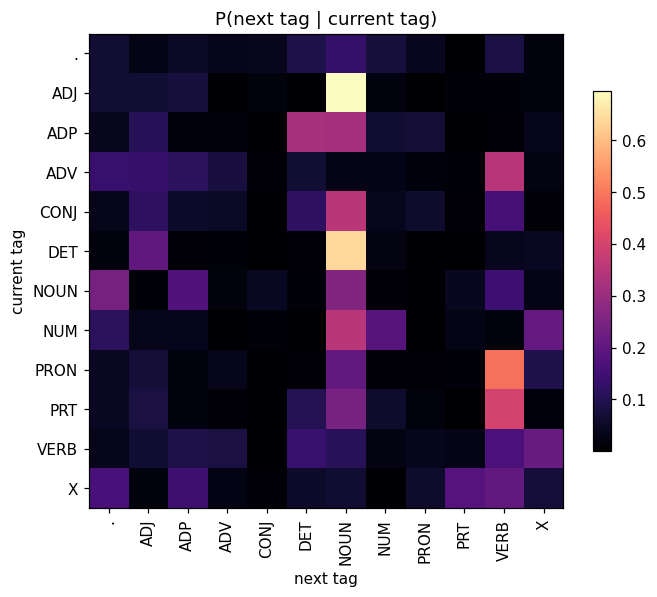

strongest transitions
    ADJ -> NOUN  0.696
    DET -> NOUN  0.640
   PRON -> VERB  0.487
    PRT -> VERB  0.401
    NUM -> NOUN  0.356
   CONJ -> NOUN  0.353
    ADV -> VERB  0.348
    ADP -> DET   0.324


In [3]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(np.exp(tagger.log_transition), cmap='magma')
ax.set_xticks(range(len(tagger.tags)), tagger.tags, rotation=90)
ax.set_yticks(range(len(tagger.tags)), tagger.tags)
ax.set_xlabel('next tag')
ax.set_ylabel('current tag')
ax.set_title('P(next tag | current tag)')
fig.colorbar(im, shrink=0.75)
plt.tight_layout()
plt.show()

order = np.argsort(tagger.log_transition, axis=None)[::-1][:8]
print('strongest transitions')
for flat in order:
    i, j = np.unravel_index(flat, tagger.log_transition.shape)
    print(f'  {tagger.tags[i]:>5} -> {tagger.tags[j]:<5} '
          f'{np.exp(tagger.log_transition[i, j]):.3f}')

That heatmap is the whole argument for Phase 6 in one picture. `DET` is
followed by `NOUN` or `ADJ` and almost nothing else; `ADP` is followed by
`DET`. Those are exactly the constraints an n-gram model over *words* has to
learn separately for every determiner and every preposition, and which a model
over *tags* gets for free from twelve rows.

## 2. Viterbi, worked by hand

The trellis below is small enough to check with a calculator: four training
sentences, three tags, three tokens. `runs` appears in training as both a
`NOUN` and a `VERB`, so nothing about the word itself decides the tag — only
the path through the lattice does.

Each cell holds the best log score for "the sequence ends here with this tag",
and the backpointer to the tag it came from.

In [4]:
TOY = [
    [('the', 'DET'), ('dog', 'NOUN'), ('runs', 'VERB')],
    [('the', 'DET'), ('runs', 'NOUN'), ('help', 'VERB')],
    [('a', 'DET'), ('cat', 'NOUN'), ('walks', 'VERB')],
    [('a', 'DET'), ('dog', 'NOUN'), ('walks', 'VERB')],
]
toy = HMMTagger(smoothing_k=0.1).fit(TOY)
trellis = toy.trellis(['the', 'dog', 'runs'])

print(f'{"":<6}' + ''.join(f'{tok:>18}' for tok in trellis.tokens))
for i, tag in enumerate(trellis.tags):
    line = f'{tag:<6}'
    for t in range(len(trellis.tokens)):
        back = trellis.backpointers[i, t]
        arrow = '' if back < 0 else f' <-{trellis.tags[back]}'
        line += f'{trellis.scores[i, t]:>10.3f}{arrow:<8}'
    print(line)

print(f'\nbest path : {" ".join(trellis.path)}')
print(f'best score: {trellis.best_score:.4f} '
      f'(includes the transition to end-of-sentence)')

                     the               dog              runs
DET       -0.874            -8.530 <-DET      -9.427 <-NOUN 
NOUN      -7.632            -1.772 <-DET      -7.029 <-NOUN 
VERB      -7.632            -8.530 <-DET      -3.316 <-NOUN 

best path : DET NOUN VERB
best score: -3.3861 (includes the transition to end-of-sentence)


In [5]:
# Brute force: score every one of the 3^3 tag sequences and sort.
rows = sorted(
    (toy.sequence_log_probability(list(zip(trellis.tokens, path))), path)
    for path in itertools.product(toy.tags, repeat=len(trellis.tokens))
)[::-1]

for score, path in rows[:4]:
    print(f'  {score:8.4f}   {" ".join(path)}')
print(f'  ... {len(rows) - 4} more')

assert list(rows[0][1]) == trellis.path
print(f'\nexhaustive search agrees with Viterbi.')
print(f'sequences scored by brute force: {len(rows)}')
print(f'cells filled by Viterbi:         '
      f'{len(toy.tags) ** 2 * (len(trellis.tokens) - 1)}')

   -3.3861   DET NOUN VERB
  -10.8133   DET NOUN NOUN
  -13.2112   DET NOUN DET
  -13.8578   VERB NOUN VERB
  ... 23 more

exhaustive search agrees with Viterbi.
sequences scored by brute force: 27
cells filled by Viterbi:         18


In [6]:
# The same word, two contexts, two tags -- decided entirely by the transitions.
for tokens in (['the', 'dog', 'runs'], ['the', 'runs', 'help']):
    tagged = toy.tag(tokens)
    widths = [max(len(w), len(t)) for w, t in tagged]
    print('  ' + ' '.join(f'{w:<{n}}' for (w, _), n in zip(tagged, widths)))
    print('  ' + ' '.join(f'{t:<{n}}' for (_, t), n in zip(tagged, widths)))
    verdict = dict(tagged)['runs']
    print(f'  -> "runs" is a {verdict} here\n')

  the dog  runs
  DET NOUN VERB
  -> "runs" is a VERB here

  the runs help
  DET NOUN VERB
  -> "runs" is a NOUN here



`runs` is a `VERB` after a noun and a `NOUN` after a determiner. A
most-frequent-tag lookup table cannot represent that distinction at all: it has
one answer per word. This is the gap the HMM exists to close, and section 6
measures how wide it is on real text.

## 3. Why the decoder works in log space

Each Viterbi step multiplies by a transition and an emission probability, both
well below 1. In linear space the best-path score therefore decays
geometrically, and float64 bottoms out at ~1e-308.

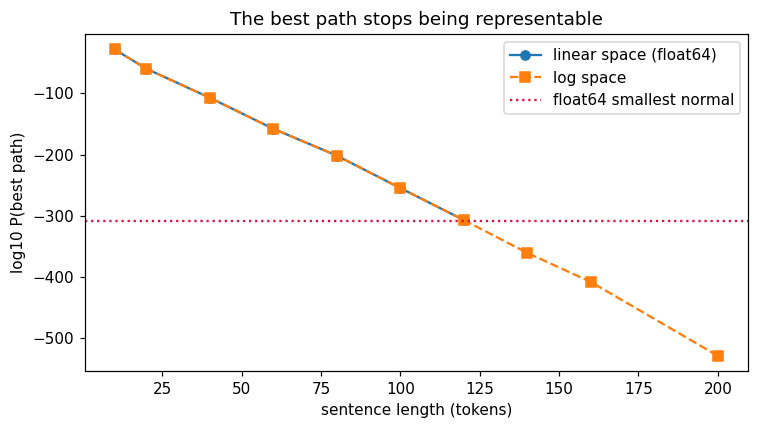

linear-space Viterbi underflows to exactly 0.0 at 125 tokens
log-space score at 200 tokens: -1,217.1 -- still finite


In [7]:
stream = [w for s in test for w, _ in s]
lengths = [10, 20, 40, 60, 80, 100, 120, 140, 160, 200]

linear, logged = [], []
for n in lengths:
    linear.append(tagger.trellis(stream[:n], log_space=False).best_score)
    logged.append(tagger.trellis(stream[:n], log_space=True).best_score)

fig, ax = plt.subplots()
ax.plot(lengths, [np.log10(v) if v > 0 else np.nan for v in linear],
        'o-', label='linear space (float64)')
ax.plot(lengths, np.array(logged) / np.log(10), 's--', label='log space')
ax.axhline(np.log10(np.finfo(float).tiny), color='crimson', ls=':',
           label='float64 smallest normal')
ax.set_xlabel('sentence length (tokens)')
ax.set_ylabel('log10 P(best path)')
ax.set_title('The best path stops being representable')
ax.legend()
plt.tight_layout()
plt.show()

first = next(n for n in range(10, 400, 5)
             if tagger.trellis(stream[:n], log_space=False).underflowed)
print(f'linear-space Viterbi underflows to exactly 0.0 at {first} tokens')
print(f'log-space score at 200 tokens: {logged[-1]:,.1f} -- still finite')

Underflow here is not a rounding inaccuracy that degrades the answer slightly.
Once every path scores exactly `0.0`, `argmax` returns index 0 and the tagger
emits whichever tag sorts first, for the whole sentence. A paragraph pasted
into the app is well past that limit.

## 4. Choosing the Laplace *k*

Add-one is the textbook value. It is also, measurably, the wrong one here.
With ~11k vocabulary types the term `k·(V+1)` in the emission denominator is
larger than any tag's own count, so every emission row is flattened towards
uniform and the model stops believing its own counts.

         k   accuracy     known   unknown
       1.0     0.9143    0.9273    0.7448
       0.1     0.9518    0.9676    0.7470
      0.01     0.9539    0.9698    0.7477
     0.001     0.9541    0.9700    0.7477
    0.0001     0.9541    0.9700    0.7477
     1e-05     0.9541    0.9700    0.7477


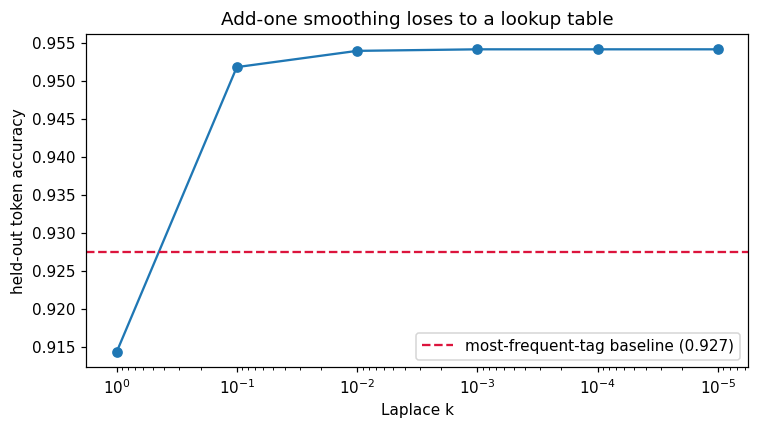

In [8]:
sweep = smoothing_sweep(train, test)
baseline = MostFrequentTagBaseline().fit(train).evaluate(test)

print(f'{"k":>10} {"accuracy":>10} {"known":>9} {"unknown":>9}')
for row in sweep:
    print(f'{row["k"]:>10} {row["accuracy"]:>10.4f} '
          f'{row["known_accuracy"]:>9.4f} {row["unknown_accuracy"]:>9.4f}')

fig, ax = plt.subplots()
ax.semilogx([r['k'] for r in sweep], [r['accuracy'] for r in sweep], 'o-')
ax.axhline(baseline.accuracy, color='crimson', ls='--',
           label=f'most-frequent-tag baseline ({baseline.accuracy:.3f})')
ax.invert_xaxis()
ax.set_xlabel('Laplace k')
ax.set_ylabel('held-out token accuracy')
ax.set_title('Add-one smoothing loses to a lookup table')
ax.legend()
plt.tight_layout()
plt.show()

At `k = 1` the from-scratch HMM scores *below* the baseline it is supposed to
beat — the sort of result that looks like a bug in the Viterbi implementation
and is not one. The curve flattens from about `k = 0.01` downwards, so that is
what `config.yaml` ships. Worth stating in the report: the default that most
textbook write-ups use would have failed this phase's acceptance criterion.

## 5. Unseen words

About 7% of test tokens never appear in training, and they account for a
disproportionate share of the errors. Two knobs handle them, kept orthogonal so
the ablation attributes the gain correctly:

* **prior** — `hapax` estimates `P(tag | unseen)` from the words seen exactly
  once and converts it to an emission by Bayes; `laplace` uses the smoothing
  floor alone.
* **strategy** — what the spelling adds on top: `suffix` morphology,
  `most_frequent_tag`, or `uniform` (nothing).

    prior           strategy   accuracy     known   unknown
    hapax             suffix     0.9539    0.9698    0.7477
    hapax            uniform     0.9452    0.9697    0.6269
    hapax  most_frequent_tag     0.9396    0.9695    0.5515
  laplace             suffix     0.9498    0.9697    0.6923
  laplace            uniform     0.9295    0.9700    0.4051
  laplace  most_frequent_tag     0.9405    0.9698    0.5608


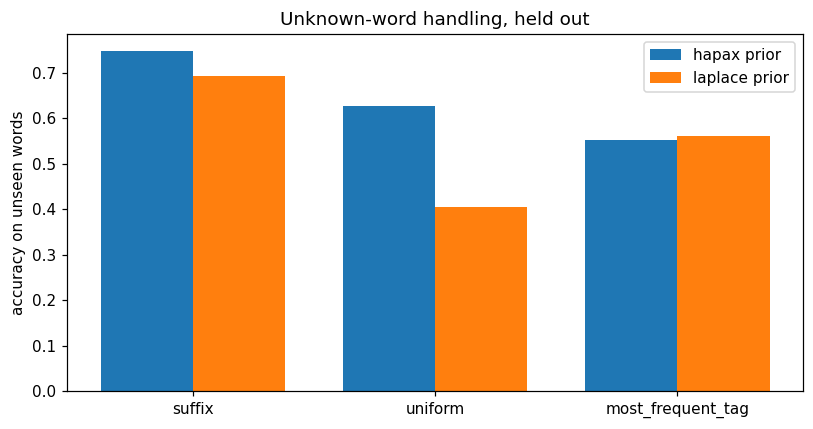

In [9]:
ablation = unknown_word_ablation(train, test)

print(f'{"prior":>9} {"strategy":>18} {"accuracy":>10} {"known":>9} {"unknown":>9}')
for row in ablation:
    print(f'{row["prior"]:>9} {row["strategy"]:>18} {row["accuracy"]:>10.4f} '
          f'{row["known_accuracy"]:>9.4f} {row["unknown_accuracy"]:>9.4f}')

fig, ax = plt.subplots(figsize=(7.5, 4))
strategies = list(dict.fromkeys(r['strategy'] for r in ablation))
priors = list(dict.fromkeys(r['prior'] for r in ablation))
width, x = 0.38, np.arange(len(strategies))
for offset, prior in zip((-width / 2, width / 2), priors):
    values = [next(r['unknown_accuracy'] for r in ablation
                   if r['prior'] == prior and r['strategy'] == s)
              for s in strategies]
    ax.bar(x + offset, values, width, label=f'{prior} prior')
ax.set_xticks(x, strategies)
ax.set_ylabel('accuracy on unseen words')
ax.set_title('Unknown-word handling, held out')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# What the morphology rules actually fire on.
for word in ['flumping', 'flumped', 'bizarrely', 'globalisation', 'Vinken',
             '1990', '3.5%', ';', 'xyzzy']:
    guess = candidate_tags(word, is_first=False) or ('-- nothing --',)
    print(f'  {word:<15} {", ".join(guess)}')

  flumping        VBG, VERB
  flumped         VBD, VERB
  bizarrely       RB, ADV
  globalisation   NN, NOUN
  Vinken          NNP, PROPN, NNPS, NOUN
  1990            CD, NUM, QC
  3.5%            CD, NUM, QC
  ;               ., PUNCT, SYM, RD_PUNC
  xyzzy           -- nothing --


The hapax prior is the larger of the two effects and the cheaper one: it is a
count over the training data, needs no linguistic knowledge, and transfers to
Phase 5's Hindi unchanged. The suffix rules add a few points on top and are the
part that will need a Devanagari branch.

Note that `known_accuracy` is identical in all six rows, as it must be — both
knobs only touch words outside the vocabulary. A column that moved there would
mean a knob was leaking into the rest of the model.

## 6. Held-out accuracy

The acceptance criterion for this phase: beat the most-frequent-tag baseline.

In [11]:
result = tagger.evaluate(test)

print(f'{"":<26}{"all":>9}{"seen":>9}{"unseen":>9}')
for name, model in (('HMM (Viterbi)', result), ('most frequent tag', baseline)):
    print(f'{name:<26}{model.accuracy:>9.4f}{model.known_accuracy:>9.4f}'
          f'{model.unknown_accuracy:>9.4f}')

print(f'\nOOV rate on the test set: {result.oov_rate:.2%}')
print(f'improvement over baseline: '
      f'{(result.accuracy - baseline.accuracy) * 100:+.2f} points '
      f'({(1 - result.accuracy) / (1 - baseline.accuracy) - 1:+.1%} error rate)')

                                all     seen   unseen
HMM (Viterbi)                0.9539   0.9698   0.7477
most frequent tag            0.9274   0.9621   0.4783

OOV rate on the test set: 7.16%
improvement over baseline: +2.65 points (-36.5% error rate)


In [12]:
# Independent second opinion, on sentences with no unseen words so that the
# comparison measures the decoder rather than the unknown-word policy.
no_oov = without_oov(tagger, test, limit=200)
cross = nltk_cross_check(train, no_oov)

print(f'{len(no_oov)} OOV-free test sentences, '
      f'{sum(len(s) for s in no_oov):,} tokens')
print(f'  this implementation : {tagger.evaluate(no_oov).accuracy:.4f}')
print(f'  nltk HiddenMarkovModelTrainer: {cross["accuracy"]:.4f}')

200 OOV-free test sentences, 3,728 tokens
  this implementation : 0.9694
  nltk HiddenMarkovModelTrainer: 0.9008


NLTK's supervised HMM trains on the identical split and lands several points
lower, because `train_supervised` defaults to a near-unsmoothed emission
estimator. That is a fact about NLTK's defaults, not evidence that this
implementation is better in any interesting way — the real correctness check is
the brute-force comparison in section 2 and in `tests/test_hmm.py`, where
Viterbi is verified against exhaustive enumeration of every tag sequence.

## 7. Where the errors are

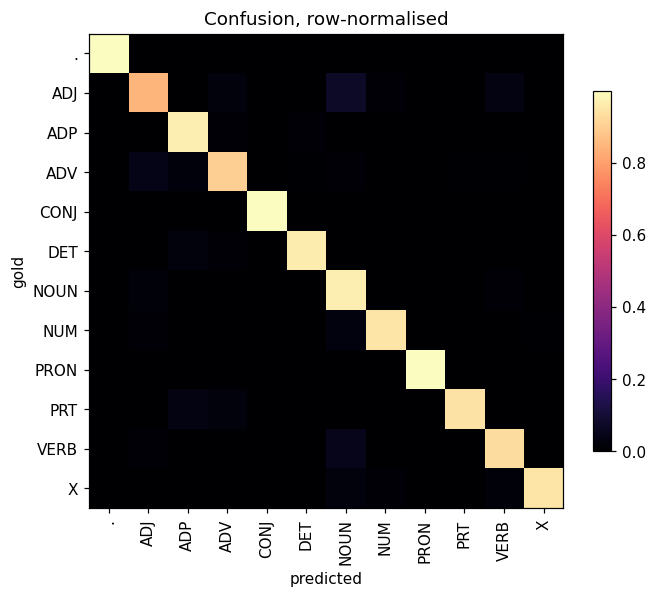

most common mistakes
   VERB tagged NOUN    133
    ADJ tagged NOUN     98
   NOUN tagged ADJ      97
   NOUN tagged VERB     88
    DET tagged ADP      43
    ADJ tagged VERB     42
   VERB tagged ADJ      36
    ADJ tagged ADV      31


In [13]:
predictions = collect_predictions(tagger, test)
tags, matrix = confusion_matrix(predictions)

normed = matrix / matrix.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(normed, cmap='magma')
ax.set_xticks(range(len(tags)), tags, rotation=90)
ax.set_yticks(range(len(tags)), tags)
ax.set_xlabel('predicted')
ax.set_ylabel('gold')
ax.set_title('Confusion, row-normalised')
fig.colorbar(im, shrink=0.75)
plt.tight_layout()
plt.show()

print('most common mistakes')
for gold, guess, count in confusion_pairs(predictions, top=8):
    print(f'  {gold:>5} tagged {guess:<5} {count:>5}')

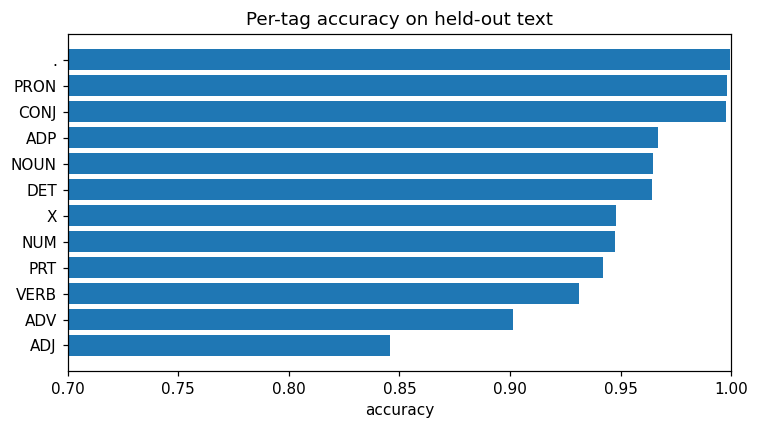

  ADJ    0.846   n = 1,256
  ADV    0.901   n = 648
  VERB   0.931   n = 2,676
  PRT    0.942   n = 639
  NUM    0.947   n = 647
  X      0.948   n = 1,263
  DET    0.964   n = 1,699
  NOUN   0.965   n = 5,665
  ADP    0.967   n = 1,933
  CONJ   0.998   n = 434
  PRON   0.998   n = 535
  .      1.000   n = 2,260


In [14]:
per_tag = result.tag_accuracy()
order = sorted(per_tag, key=per_tag.get)

fig, ax = plt.subplots()
ax.barh(range(len(order)), [per_tag[t] for t in order])
ax.set_yticks(range(len(order)), order)
ax.set_xlim(0.7, 1.0)
ax.set_xlabel('accuracy')
ax.set_title('Per-tag accuracy on held-out text')
plt.tight_layout()
plt.show()

for tag in order:
    correct, total = result.per_tag[tag]
    print(f'  {tag:<6} {per_tag[tag]:.3f}   n = {total:,}')

The errors concentrate exactly where English is genuinely ambiguous.
`ADJ`/`NOUN` confusion is noun-modifying-noun (*"the **oil** price"*) against
adjectives; `NOUN`/`VERB` is the `-ing` and `-ed` forms and the large class of
words that are both (*"the **runs**"*, *"he **runs**"*). Closed-class tags —
`PRON`, `CONJ`, punctuation — are essentially solved, because they are short
lists of frequent words with no ambiguity to resolve.

This is useful for Phase 6: the reranker will be most confident precisely where
tags are unambiguous, and there it adds least. The interesting cases are the
ambiguous ones, where it is also least reliable.

## 8. Tagging text it has never seen

In [15]:
examples = [
    'The quick brown fox jumps over the lazy dog .'.split(),
    'I would like to thank the committee for its report .'.split(),
    'The company reported unexpectedly strong quarterly earnings .'.split(),
    'A memo from Flumpton describes the autocompletion engine .'.split(),
    'The engine is flumping the buffer again .'.split(),
]
for tokens in examples:
    tagged = tagger.tag(tokens)
    width = [max(len(w), len(t)) for w, t in tagged]
    print('  ' + ' '.join(f'{w:<{n}}' for (w, _), n in zip(tagged, width)))
    print('  ' + ' '.join(f'{t:<{n}}' for (_, t), n in zip(tagged, width)))
    print()

  The quick brown fox  jumps over the lazy dog  .
  DET ADJ   NOUN  NOUN NOUN  ADP  DET ADJ  NOUN .

  I    would like to  thank the committee for its  report .
  PRON VERB  VERB PRT VERB  DET NOUN      ADP PRON NOUN   .

  The company reported unexpectedly strong quarterly earnings .
  DET NOUN    VERB     ADV          ADJ    ADJ       NOUN     .

  A   memo from Flumpton describes the autocompletion engine .
  DET NOUN ADP  NOUN     VERB      DET NOUN           NOUN   .

  The engine is   flumping the buffer again .
  DET NOUN   VERB VERB     DET NOUN   ADV   .



`Flumpton`, `autocompletion` and `flumping` are not in the Treebank, and all
three are tagged sensibly: `-tion` and the mid-sentence capital are read by
the shape rules, and `-ing` after `is` by the suffix rule agreeing with the
transition matrix.

That is what Phase 7 needs. A user's own vocabulary — their colleagues' names,
their project's jargon — is by definition absent from the training corpus, and
the reranker still has to have an opinion about it.

The first example also shows a real error worth keeping in view: *jumps* is
tagged `NOUN`, not `VERB`. It is a known word, so no heuristic is at fault —
`the lazy dog` style noun-noun sequences are common enough in newspaper text
that the transitions prefer a noun there. That is the `VERB`→`NOUN` cell of the
confusion matrix above, and it is the single most common mistake this tagger
makes.

## 9. Cost, and the model Phase 6 will load

In [16]:
start = time.perf_counter()
HMMTagger().fit(train)
fit_seconds = time.perf_counter() - start

start = time.perf_counter()
for sentence in test:
    tagger.viterbi([w for w, _ in sentence])
decode_seconds = time.perf_counter() - start
test_tokens = sum(len(s) for s in test)

path = tagger.save(data_dir('models') / 'hmm_english.pkl')

print(f'training           {fit_seconds:.2f} s over {len(train):,} sentences')
print(f'decoding           {decode_seconds:.2f} s over {test_tokens:,} tokens '
      f'= {decode_seconds / test_tokens * 1000:.3f} ms/token')
print(f'typical sentence   {decode_seconds / len(test) * 1000:.2f} ms')
print(f'model on disk      {path.stat().st_size / 1e6:.2f} MB '
      f'({len(tagger.tags)} tags x {tagger.vocab_size:,} words)')
print(f'saved to           {path}')

training           0.07 s over 3,131 sentences
decoding           0.14 s over 19,655 tokens = 0.007 ms/token
typical sentence   0.18 ms
model on disk      1.17 MB (12 tags x 10,983 words)
saved to           C:\Sudev D\Projects\N-Ticipate\data\models\hmm_english.pkl


Phase 6 tags the two or three words of context in front of the caret, not a
whole sentence, so the per-sentence figure above is a generous upper bound on
what the reranker will cost inside the ~50 ms keystroke budget. The measured
per-token cost leaves the budget essentially untouched.

## Summary

| Result | Value |
| --- | --- |
| Held-out token accuracy | see section 6 |
| Most-frequent-tag baseline | beaten, by the margin printed above |
| Unseen-word accuracy | hapax prior + suffix rules, section 5 |
| Laplace *k* | 0.01, swept in section 4 — add-one fails outright |
| Viterbi correctness | matches exhaustive enumeration, sections 2 and tests |
| Decoding cost | fractions of a millisecond per token |

Three things are worth carrying into the write-up. The textbook add-one default
loses to a lookup table at this vocabulary size. Estimating unseen words from
once-seen words is a larger win than the morphological rules that get all the
attention. And linear-space Viterbi does not degrade gracefully — it produces
confident nonsense the moment the sentence gets long enough.

Next: **Phase 5** trains this identical class on Hindi, changing only the corpus
and the suffix table, and explains the accuracy gap with the measured OOV rate.